In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data
from detection_inference import predict, load_model
from pathlib import Path
from depth import get_box_centers_with_disparity
plt.gray()

C:\Users\adish\Desktop\DTU\pfas\Perception-AutonomousSystems
C:\Users\adish\Desktop\DTU\pfas\Perception-AutonomousSystems\Project


<Figure size 640x480 with 0 Axes>

In [2]:
PROJECT_ROOT = Path(r"C:\Users\adish\Desktop\DTU\pfas\Perception-AutonomousSystems\Project")
print(PROJECT_ROOT)
model = load_model(PROJECT_ROOT / 'working_files/weights/best.pt')

C:\Users\adish\Desktop\DTU\pfas\Perception-AutonomousSystems\Project
Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
Model loaded from best.pt


In [3]:
img_left = cv2.imread(r"C:\Users\adish\Desktop\DTU\pfas\34759_final_project_rect\seq_01\image_02\data\000000.png")
img_right = cv2.imread(r"C:\Users\adish\Desktop\DTU\pfas\34759_final_project_rect\seq_01\image_03\data\000000.png")
results=predict(img_left,model)
r = results[0]
r.boxes



ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1.])
conf: tensor([0.8842, 0.7795])
data: tensor([[382.9427, 141.3022, 490.4506, 363.8414,   0.8842,   1.0000],
        [487.1156, 137.7665, 551.4376, 335.5353,   0.7795,   1.0000]])
id: None
is_track: False
orig_shape: (370, 1224)
shape: torch.Size([2, 6])
xywh: tensor([[436.6967, 252.5718, 107.5078, 222.5392],
        [519.2766, 236.6509,  64.3220, 197.7689]])
xywhn: tensor([[0.3568, 0.6826, 0.0878, 0.6015],
        [0.4242, 0.6396, 0.0526, 0.5345]])
xyxy: tensor([[382.9427, 141.3022, 490.4506, 363.8414],
        [487.1156, 137.7665, 551.4376, 335.5353]])
xyxyn: tensor([[0.3129, 0.3819, 0.4007, 0.9834],
        [0.3980, 0.3723, 0.4505, 0.9069]])

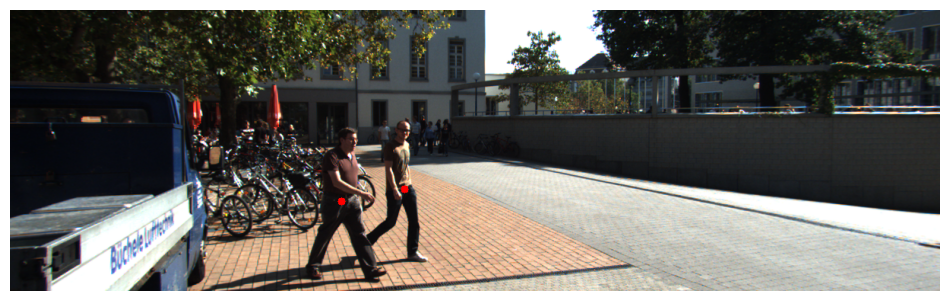

In [4]:

img_points = img_left.copy()

for box in r.boxes.xyxy:
    x1, y1, x2, y2 = box.tolist()

    # sredine
    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)

    # crtanje crvene tačke
    cv2.circle(img_points, (cx, cy), radius=5, color=(0, 0, 255), thickness=-1)
    
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_points, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


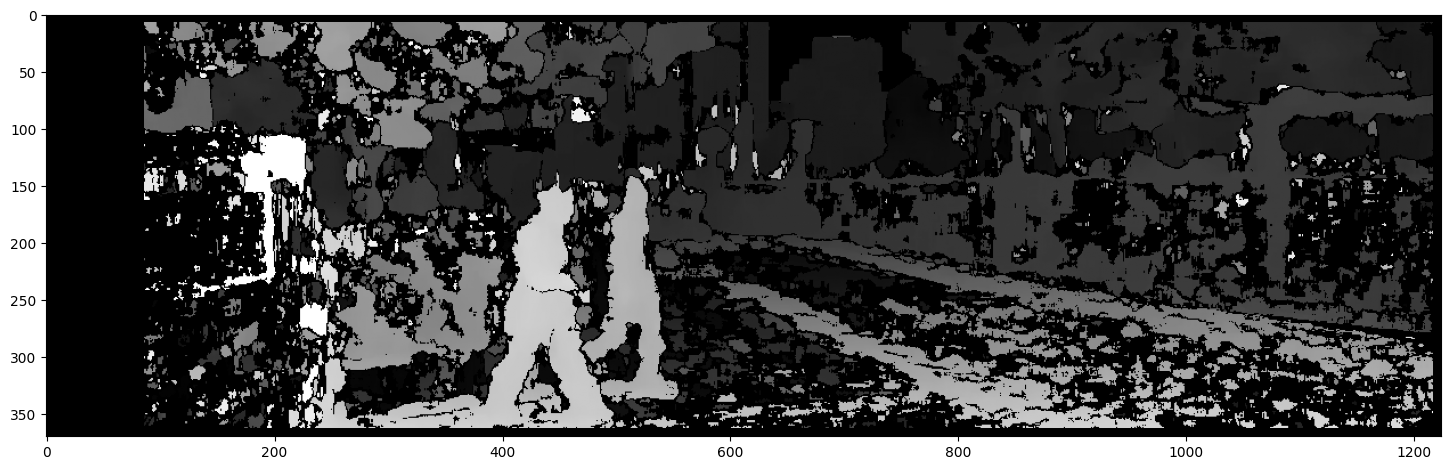

In [5]:

# convert images to grayscale for template matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)


min_disp = 0
num_disp = 5 * 16
block_size = 15
stereo = cv2.StereoBM_create(numDisparities = num_disp, blockSize = block_size)
stereo.setMinDisparity(min_disp)
stereo.setDisp12MaxDiff(200)
stereo.setUniquenessRatio(10)
stereo.setSpeckleRange(10)
stereo.setSpeckleWindowSize(1)

disp = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

plt.figure(figsize=(18,18))
plt.imshow(disp)



In [6]:
get_box_centers_with_disparity(img_left,img_right)

Model summary (fused): 72 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
Model loaded from best.pt


[(436, 252, 1.116650104522705), (519, 236, 1.2785388231277466)]